In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import xgboost 
from sklearn.manifold import TSNE
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, 
)

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)


In [2]:

df = pd.read_csv('Copia de data_merged.csv')



In [3]:

def aux(temp):
    if temp<=80:
        return 'lento'
    elif temp <=120:
        return 'moderado'
    return 'rapido'

df['duration_ms']= df['duration_ms']/60000
df['duration_ms_ar'] = df['duration_ms_ar']/60000
df['duration_ms_yr'] = df['duration_ms_yr']/60000

df['energy_ratio_yr'] = df['energy_yr']*df['acousticness_yr']
df['electro_focus_yr'] = (1-df['acousticness_yr'])*df['energy_yr']*df['instrumentalness_yr']
df['vocal_energy_yr'] = (1-df['instrumentalness_yr'])*df['energy_yr']

df['energy_ratio_'] = df['energy']*df['acousticness']
df['electro_focus'] = (1-df['acousticness'])*df['energy']*df['instrumentalness']
df['vocal_energy'] = (1-df['instrumentalness'])*df['energy']

df['energy_ratio_ar'] = df['energy_ar']*df['acousticness_ar']
df['electro_focus_ar'] = (1-df['acousticness_ar'])*df['energy_ar']*df['instrumentalness_ar']
df['vocal_energy_ar'] = (1-df['instrumentalness_ar'])*df['energy_ar']


df['temp_range'] = df['tempo_yr'].apply(aux)
df = pd.get_dummies(df,columns=['temp_range'],prefix='temp')
df[['temp_moderado','temp_rapido']] = df[['temp_moderado','temp_rapido']].astype(int)

In [4]:
df

,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,liveness,loudness,popularity,speechiness,...,electro_focus_yr,vocal_energy_yr,energy_ratio_,electro_focus,vocal_energy,energy_ratio_ar,electro_focus_ar,vocal_energy_ar,temp_moderado,temp_rapido
0,0.013100,0.2560,3.039117,0.895,0,0.000106,0.0821,-4.860,29,0.0707,...,0.037649,0.495522,0.011725,0.000094,0.894905,0.105519,1.463051e-02,0.709725,0,1
1,0.980000,0.2770,3.449533,0.145,0,0.879000,0.1110,-19.898,0,0.0845,...,0.009108,0.183282,0.142100,0.002549,0.017545,0.208915,4.504740e-03,0.097838,1,0
2,0.795000,0.6850,5.244450,0.483,0,0.878000,0.1130,-10.202,1,0.0337,...,0.010180,0.186780,0.383985,0.086935,0.058926,0.491828,6.804020e-02,0.059278,1,0
3,0.656000,0.7880,2.995783,0.808,0,0.000000,0.1540,-6.590,0,0.0395,...,0.010180,0.186780,0.530048,0.000000,0.808000,0.537642,2.723306e-07,0.744999,1,0
4,0.302000,0.0753,8.309333,0.150,0,0.884000,0.1210,-16.705,0,0.0371,...,0.007777,0.179243,0.045300,0.092555,0.017400,0.253033,3.753181e-02,0.103445,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172225,0.000067,0.5670,0.616667,0.862,0,0.875000,0.4810,-5.617,0,0.0670,...,0.116161,0.507938,0.000058,0.754199,0.107750,0.000040,5.311705e-01,0.370306,0,1
172226,0.000994,0.3960,8.363733,0.979,0,0.609000,0.1360,-9.138,0,0.0878,...,0.133639,0.491948,0.000973,0.595618,0.382789,0.016665,1.873520e-01,0.759704,0,1
172227,0.864000,0.6380,2.692667,0.156,0,0.000000,0.1830,-17.372,20,0.0741,...,0.013051,0.250225,0.134784,0.000000,0.156000,0.131158,2.533831e-04,0.142178,1,0
172228,0.029900,0.5330,5.713783,0.547,0,0.011300,0.0723,-9.290,35,0.0326,...,0.031967,0.443442,0.016355,0.005996,0.540819,0.098186,1.820001e-02,0.678454,1,0


In [5]:

df_processed = df.copy()

initial_rows = len(df_processed)
df_processed = df_processed.dropna()

def categorize_popularity(popularity):
    if popularity<=20:
        return 0 # baja
    elif popularity <=45:
        return 1 # media
    return 2 # alta
    

df_processed['popularity_multiclass'] = df_processed['popularity'].apply(categorize_popularity)
print("\nVariable multiclase 3 niveles (popularity_multiclass):")
multiclass_counts = df_processed['popularity_multiclass'].value_counts().sort_index()
multiclass_labels = ['Baja', 'Media', 'Alta']
for i, (count, label) in enumerate(zip(multiclass_counts, multiclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")




Variable multiclase 3 niveles (popularity_multiclass):
   0 (Baja): 73762 (42.8%)
   1 (Media): 62074 (36.0%)
   2 (Alta): 36394 (21.1%)


<Axes: xlabel='popularity_multiclass'>

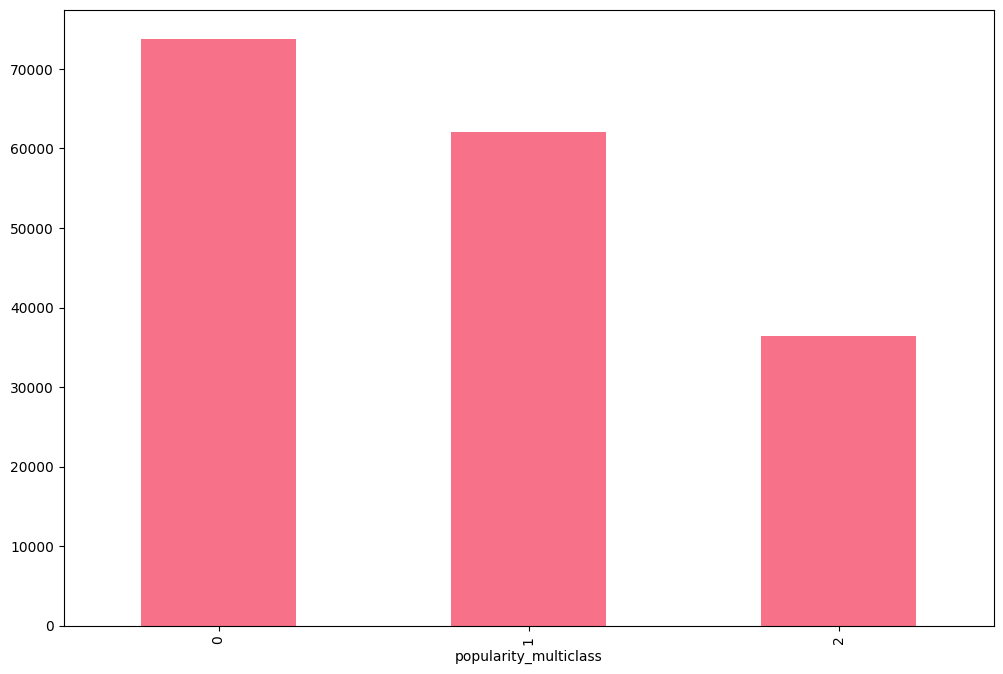

In [6]:
df_processed['popularity_multiclass'].value_counts().plot(kind='bar')

In [7]:


_X = df_processed.copy()

X = _X.drop(columns=['popularity','popularity_multiclass'])
y_multiclass_3 = df_processed['popularity_multiclass'] 



In [8]:
df_processed.groupby('popularity_multiclass')['popularity'].describe()

,count,mean,std,min,25%,50%,75%,max
popularity_multiclass,,,,,,,,
0,73762.0,4.438369,6.348734,0.0,0.0,0.0,8.0,20.0
1,62074.0,32.917051,6.956338,21.0,27.0,33.0,39.0,45.0
2,36394.0,57.551904,8.900427,46.0,50.0,56.0,63.0,100.0


# k=10


Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ...................................C=1, kernel=poly; total time=10.6min
[CV] END ...................................C=1, kernel=poly; total time=10.7min
[CV] END ...................................C=1, kernel=poly; total time=10.7min
[CV] END ....................................C=1, kernel=rbf; total time=14.8min
[CV] END ....................................C=1, kernel=rbf; total time=15.0min
[CV] END ....................................C=1, kernel=rbf; total time=15.0min
[CV] END ....................................C=1, kernel=rbf; total time=15.1min
[CV] END ....................................C=1, kernel=rbf; total time=15.1min
[CV] END ...................................C=1, kernel=poly; total time= 9.3min
[CV] END ...................................C=1, kernel=poly; total time= 9.4min
[CV] END ....................................C=5, kernel=rbf; total time=15.4min
[CV] END ...................................C=5, 

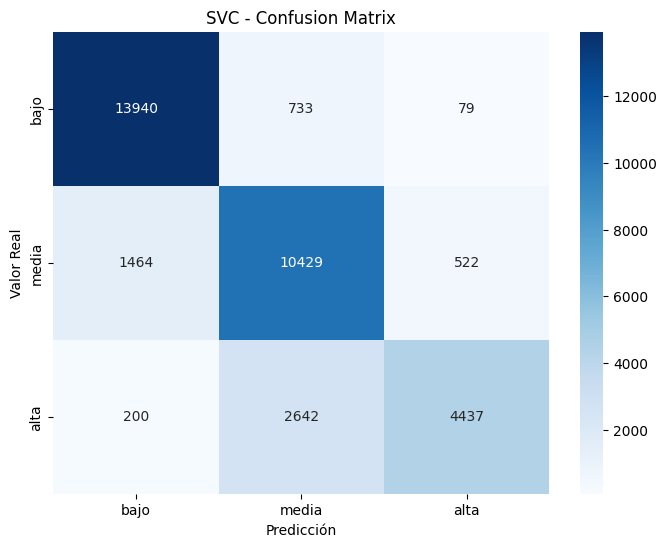


random
              precision    recall  f1-score   support

           0       0.43      0.25      0.31     14752
           1       0.37      0.25      0.30     12415
           2       0.21      0.25      0.23      7279
           3       0.00      0.00      0.00         0

    accuracy                           0.25     34446
   macro avg       0.25      0.19      0.21     34446
weighted avg       0.36      0.25      0.29     34446



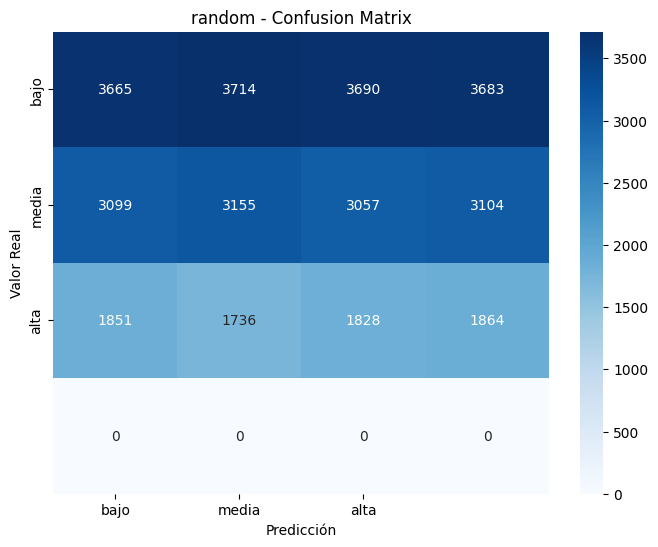

error 'SVC' object has no attribute 'feature_importances_'


In [9]:
selector = SelectKBest(score_func=f_classif,k=10)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select
_X=X[select]
y =y_multiclass_3
scaler1 = RobustScaler()

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
X_train_reduce = scaler1.fit_transform(X_train_reduce)
X_test_scaled = scaler1.transform(X_test_reduce)
models = {
    "SVC":SVC(kernel='rbf',C=1),
}

param_grids = {
    
    'SVC': {
        'kernel':['rbf','poly'],
        "C":[1,5,0.01,10]
    }
}
results = {}

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1,verbose=2)
    grid.fit(X_train_reduce, y_train_reduce)
    best = grid.best_estimator_
    y_pred = best.predict(X_test_scaled)
    r = classification_report(y_test_reduce, y_pred)
    print(f"\n{name}")
    print(f"Best params: {grid.best_params_}")
    print(r)
    cm = confusion_matrix(y_test_reduce, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

    y_random = np.random.randint(0,4,size=len(y_test_reduce))
    print(f"\nrandom")
    r = classification_report(y_test_reduce, y_random)
    print(r)
    cm = confusion_matrix(y_test_reduce, y_random)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[ 'bajo','media','alta'],
                yticklabels=['bajo','media','alta'])
    plt.title(f'random - Confusion Matrix')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()
    features = []
    if hasattr(best,'feature_importances_'):
        features = best.feature_importances_
    try:
        print(best.feature_importances_)
        plt.bar(_X.columns,height=features)
        plt.xticks(rotation=90)
        plt.title(f"{name}")
        plt.show()
    except Exception as e: 
        print("error",e)
    results[name] = grid.best_params_